# Concrete damage classification

## Quick start

```bash
python -m pip install -r requirements.txt
jupyter lab main.ipynb
```

1. Set `DATA_DIR` to the folder containing the images and `labels.csv`.
2. Set `RUN_TRAINING`: `False` loads the supplied neural-network weights; `True` retrains both networks.
3. Select **Restart Kernel and Run All Cells**.

Place the supplied weights in `models/`. LightGBM is fitted if its saved model is missing. New weights, plots and tables go in `output/`.

## 1. Task overview

Classify concrete damage crops as **corrosion (0)** or **crack (1)**.

The workflow follows the presentation: data preparation, evaluation, neural networks, feature analysis and LightGBM.


In [1]:
import json
from datetime import datetime
from pathlib import Path

PROJECT = Path.cwd()
DATA_DIR = (PROJECT / '../../test_data_scientist/test_data_scientist').resolve()
MODEL_DIR = PROJECT / 'models'
RUN_TRAINING = False

mode = 'train' if RUN_TRAINING else 'load'
WORK_DIR = PROJECT / 'output' / f"{mode}_{datetime.now():%Y%m%d_%H%M%S_%f}"
if not (PROJECT / 'config.json').is_file():
    raise FileNotFoundError('Start Jupyter in the folder containing main.ipynb.')
if not (DATA_DIR / 'labels.csv').is_file():
    raise FileNotFoundError(f'Set DATA_DIR to the folder containing labels.csv and the images: {DATA_DIR}')
config = json.loads((PROJECT / 'config.json').read_text(encoding='utf-8'))
WORK_DIR.mkdir(parents=True)

In [2]:
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image, ImageOps
from sklearn.metrics import precision_recall_curve, roc_curve
from torch.utils.data import DataLoader

from src.data import (
    DamageDataset, audit_images, augment_training_rows, evaluation_transform,
    load_splits, prepare_training_rows, render_crop, resize_and_pad, stable_choice,
)
from src.evaluate import metric_summary, predict_dataset
from src.models import load_model
from src.train import set_seed, train_resnet18, train_small_cnn

set_seed(config['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = {0: 'corrosion', 1: 'crack'}
print('Python:', platform.python_version(), '| PyTorch:', torch.__version__)
print('device:', device, '| seed:', config['seed'], '| training:', RUN_TRAINING)
print('data:', DATA_DIR)
display(config)


Python: 3.13.9 | PyTorch: 2.11.0+cu128
device: cuda | seed: 42 | training: False
data: D:\MYL_个人\个人\EDF\Coding_Test\test_data_scientist\test_data_scientist


{'id': 'seeded-visual-slices-v2',
 'seed': 42,
 'threshold': 0.5,
 'batch_size': 64,
 'small_cnn': {'max_epochs': 40,
  'min_epochs': 10,
  'patience': 6,
  'min_delta': 0.001},
 'resnet18': {'head_max_epochs': 10,
  'head_min_epochs': 3,
  'head_patience': 3,
  'finetune_max_epochs': 20,
  'finetune_min_epochs': 6,
  'finetune_patience': 5,
  'min_delta': 0.001},
 'notes': 'Image size is fixed at 224 in data.py. Architecture, optimizer and learning rates are explicit in models.py and train.py. All initially uncertain slices are excluded.',
 'num_workers': 4}

## 2. Data preparation

Read the labels and count each class. The filename prefix before `_crop_` identifies the source image; all its crops share one split.


In [3]:
raw_labels = pd.read_csv(DATA_DIR / 'labels.csv')
display(raw_labels.head())
display(raw_labels['label'].map(class_names).value_counts().rename('label_rows').to_frame())
print('Example source ID:', raw_labels.iloc[0]['name'].split('_crop_')[0])

,name,label
0,image_0001369_crop_0000006.png,0
1,image_0001235_crop_0000001.png,0
2,image_0001120_crop_0000004.png,1
3,image_0001583_crop_0000005.png,0
4,image_0001497_crop_0000006.png,0


,label_rows
label,
crack,2272
corrosion,1321


Example source ID: image_0001369


Use the 3,590 matched image-label pairs. Log the three missing images and two unlabelled images.

The saved seed-42 split contains **2,512 training, 346 validation and 732 test images**. Ten stratified source-group folds assign 0-1 to test, 2 to validation and the rest to training. `config.seed` controls training and rotations; the saved split stays fixed.


In [4]:
# Match labels and restore the saved source-group split.
train_df, val_df, test_df, audit = load_splits(
    DATA_DIR, PROJECT / 'support/split_manifest.csv'
)
display(audit)

all_rows = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_counts = pd.crosstab(all_rows['split'], all_rows['label']).reindex(['train', 'val', 'test'])
split_counts = split_counts.rename(columns=class_names)
split_counts['total'] = split_counts[['corrosion', 'crack']].sum(axis=1)
split_counts['source_images'] = all_rows.groupby('split')['source_id'].nunique()
split_counts['crack_fraction'] = split_counts['crack'] / split_counts['total']
display(split_counts.round(3))

train_sources = set(train_df['source_id'])
val_sources = set(val_df['source_id'])
test_sources = set(test_df['source_id'])
assert train_sources.isdisjoint(val_sources)
assert train_sources.isdisjoint(test_sources)
assert val_sources.isdisjoint(test_sources)
print('Train, validation and test source IDs are disjoint.')

{'label_rows': 3593,
 'image_files': 3592,
 'matched_samples': 3590,
 'labels_without_image': ['image_0000021_crop_0000001.png',
  'image_0001463_crop_0000002.png',
  'image_0001533_crop_0000001.png'],
 'images_without_label': ['image_0001251_crop_0000005.png',
  'image_0001594_crop_0000005.png'],
 'policy': 'List unmatched records; review corrupt files and duplicates before training.'}

label,corrosion,crack,total,source_images,crack_fraction
split,,,,,
train,894,1618,2512,583,0.644
val,137,209,346,91,0.604
test,288,444,732,170,0.607


Train, validation and test source IDs are disjoint.


Check image readability and exact duplicates before proceeding.


In [5]:
# Decode images and check for exact duplicates.
image_audit = audit_images(all_rows)
print('checked:', image_audit['checked_images'])
print('corrupt:', len(image_audit['corrupt']), '| duplicate rows:', len(image_audit['duplicates']))
if image_audit['corrupt'] or image_audit['duplicates']:
    display(image_audit)
    raise ValueError('Corrupt or duplicate images found; see the audit table.')
_ = (WORK_DIR / 'data_audit.json').write_text(
    json.dumps({'files': audit, 'images': image_audit}, ensure_ascii=False, indent=2), encoding='utf-8'
)

checked: 3590
corrupt: 0 | duplicate rows: 0


### 2.1 Image examples and dimensions

Show three training examples per class and inspect image sizes and aspect ratios.


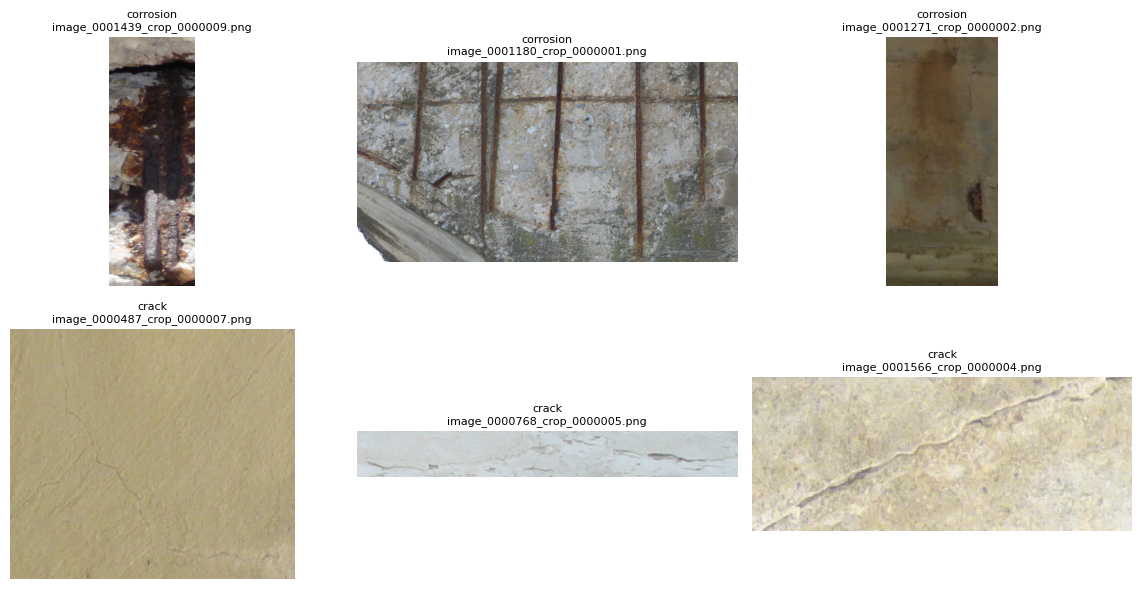

In [6]:
examples = pd.concat([
    train_df[train_df['label'].eq(label)].sample(3, random_state=config['seed'])
    for label in [0, 1]
])
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for axis, row in zip(axes.flat, examples.itertuples(index=False)):
    with Image.open(row.path) as image:
        axis.imshow(ImageOps.exif_transpose(image).convert('RGB'))
    axis.set_title(f'{class_names[row.label]}\n{row.name}', fontsize=8)
    axis.axis('off')
plt.tight_layout()
fig.savefig(WORK_DIR / 'training_examples.png', dpi=140, bbox_inches='tight')
plt.show()

,width,height,aspect_ratio
count,2512.00,2512.00,2512.00
mean,747.31,700.16,3.14
std,840.11,708.32,2.25
min,33.00,30.00,1.00
25%,257.00,247.75,1.61
50%,452.00,450.00,2.53
75%,871.00,861.75,3.91
max,4848.00,3999.00,25.91


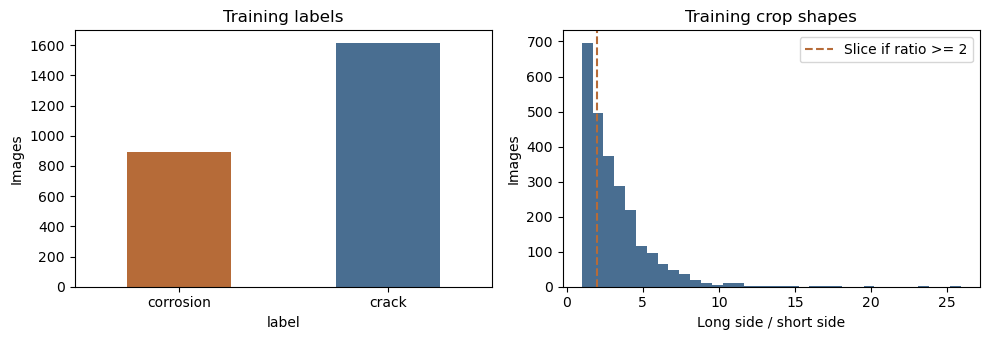

In [7]:
sizes = []
for row in train_df.itertuples(index=False):
    with Image.open(row.path) as image:
        width, height = image.size
        if image.getexif().get(274) in [5, 6, 7, 8]:
            width, height = height, width
    sizes.append({'name': row.name, 'width': width, 'height': height,
                  'aspect_ratio': max(width, height) / min(width, height)})
train_sizes = pd.DataFrame(sizes)
display(train_sizes[['width', 'height', 'aspect_ratio']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
train_df['label'].map(class_names).value_counts().reindex(['corrosion', 'crack']).plot.bar(
    ax=axes[0], rot=0, color=['#b66b38', '#496e91'], ylabel='Images', title='Training labels')
axes[1].hist(train_sizes['aspect_ratio'], bins=35, color='#496e91')
axes[1].axvline(2, color='#b66b38', linestyle='--', label='Slice if ratio >= 2')
axes[1].set(xlabel='Long side / short side', ylabel='Images', title='Training crop shapes')
axes[1].legend()
plt.tight_layout()
fig.savefig(WORK_DIR / 'training_distribution.png', dpi=140, bbox_inches='tight')
plt.show()


### 2.2 Image size normalization

Preserve aspect ratio, shrink large images and centre them on a grey 224 x 224 canvas. Small images keep their size. Scale pixels to [0, 1] and normalize with ImageNet statistics.


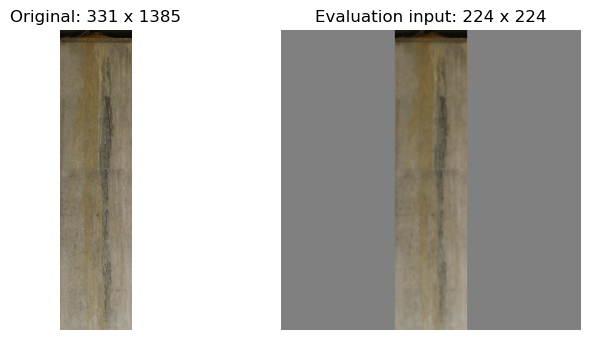

tensor shape: (3, 224, 224) | dtype: torch.float32
Normalized range: -1.964 to 1.002


In [8]:
example_path = train_df.iloc[0]['path']
with Image.open(example_path) as image:
    original = ImageOps.exif_transpose(image).convert('RGB')
padded = resize_and_pad(original.copy())
tensor = evaluation_transform()(original.copy())

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(original)
axes[0].set_title(f'Original: {original.width} x {original.height}')
axes[1].imshow(padded)
axes[1].set_title('Evaluation input: 224 x 224')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()
print('tensor shape:', tuple(tensor.shape), '| dtype:', tensor.dtype)
print('Normalized range:', round(tensor.min().item(), 3), 'to', round(tensor.max().item(), 3))

### 2.3 Slice elongated training images

For aspect ratio >= 2, divide the long side into `max(2, ceil(ratio / 2))` segments, with a 10% short-side margin at internal boundaries. Apply EXIF orientation first.

`support/slice_review.csv` stores `image_name`, `slice_index` and `keep`. Indices run from 1, left-to-right or top-to-bottom; the slicing rule regenerates coordinates.

Visual review retained **3,244 of 4,197 candidates** and excluded all 953 uncertain cases. Together with 2,512 originals, this gives **5,756 base images**. Changing the slicing rule requires reviewing the candidates again.


,count
original_train_images,2512
elongated_originals,1601
candidate_slices,4197
accepted_slices,3244
rejected_slices,953
base_images,5756
augmented_images,17268


,base_id,source_id,label,base_kind,box
0,image_0000005_crop_0000001__full,image_0000005,0,original,"(0, 0, 331, 1385)"
1,image_0000005_crop_0000002__full,image_0000005,0,original,"(0, 0, 397, 2351)"
2,image_0000034_crop_0000001__full,image_0000034,0,original,"(0, 0, 385, 2946)"
3,image_0000034_crop_0000002__full,image_0000034,1,original,"(0, 0, 411, 140)"
4,image_0000046_crop_0000001__full,image_0000046,1,original,"(0, 0, 666, 126)"


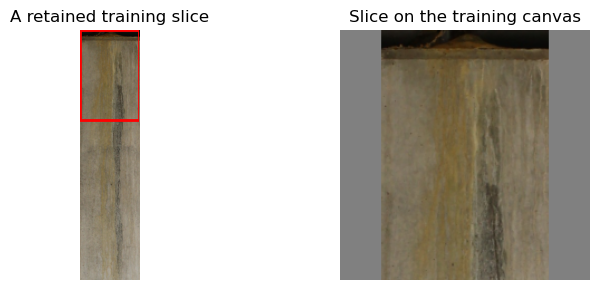

In [9]:
# Regenerate slice coordinates and apply the saved keep decisions.
base_table, augmentation_summary = prepare_training_rows(
    train_df, PROJECT / 'support/slice_review.csv'
)
display(pd.Series(augmentation_summary, name='count').to_frame())
display(base_table[['base_id', 'source_id', 'label', 'base_kind', 'box']].head())
assert set(base_table['source_id']) <= train_sources

slice_row = base_table[base_table['base_kind'].eq('slice')].iloc[0]
with Image.open(slice_row['path']) as image:
    slice_original = ImageOps.exif_transpose(image).convert('RGB')
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(slice_original)
left, top, right, bottom = slice_row['box']
axes[0].add_patch(plt.Rectangle((left, top), right-left, bottom-top, fill=False, color='red', linewidth=2))
axes[0].set_title('A retained training slice')
axes[1].imshow(render_crop(slice_row['path'], slice_row['box']))
axes[1].set_title('Slice on the training canvas')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()


### 2.4 Training augmentation

Each base image gets three seeded orientations: 0 degrees, one of 90/270, and one of 45/135/225/315. This gives **17,268 training samples**, rendered from the originals as needed.

Training images can be enlarged to fit the canvas. Validation and test images use shrinking and padding only.


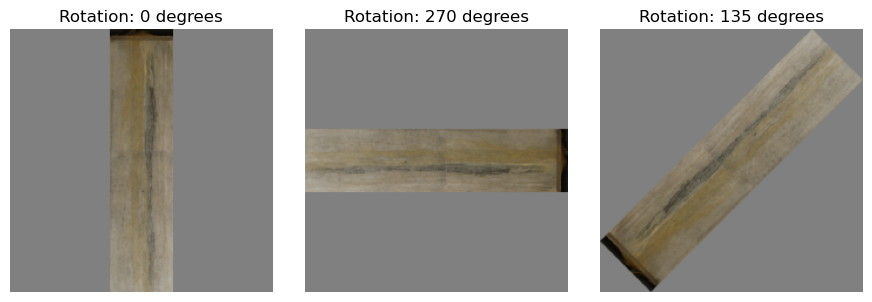

In [10]:
base = base_table.iloc[0]
angles = [
    0,
    stable_choice(f"{base['base_id']}:orthogonal", [90, 270], config['seed']),
    stable_choice(f"{base['base_id']}:diagonal", [45, 135, 225, 315], config['seed']),
]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for axis, angle in zip(axes, angles):
    axis.imshow(render_crop(base['path'], base['box'], angle))
    axis.set_title(f'Rotation: {angle} degrees')
    axis.axis('off')
plt.tight_layout()
fig.savefig(WORK_DIR / 'augmentation_preview.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Evaluation

Crack is the positive class. Predict crack when `p(crack) >= 0.5`. Validation macro-F1 selects neural-network checkpoints; the test set measures their final performance.

| Metric | Meaning |
|---|---|
| Macro-F1 | Mean F1 across both classes |
| Precision | Correct predictions / predictions for that class |
| Recall | Recovered images / images in that class |
| F1 | Harmonic mean of precision and recall |
| Accuracy | Correct predictions / all images |
| Confusion matrix | True labels in rows, predictions in columns |
| ROC-AUC | Area under the true-positive vs false-positive rate curve |
| Crack PR-AUC | Trapezoidal area under the crack precision-recall curve |

For cracks: precision = TP / (TP + FP), recall = TP / (TP + FN), and F1 = 2TP / (2TP + FP + FN).

The example below computes ROC-AUC by summing trapezoid areas.


In [11]:
from sklearn.metrics import auc

example_labels = np.array([1, 1, 0, 0])
example_scores = np.array([0.90, 0.40, 0.80, 0.20])
example_fpr, example_tpr, example_thresholds = roc_curve(example_labels, example_scores)
display(pd.DataFrame({'threshold': example_thresholds, 'FPR': example_fpr, 'TPR': example_tpr}))
print('Example ROC-AUC:', auc(example_fpr, example_tpr))

,threshold,FPR,TPR
0,inf,0.0,0.0
1,0.9,0.0,0.5
2,0.8,0.5,0.5
3,0.4,0.5,1.0
4,0.2,1.0,1.0


Example ROC-AUC: 0.75


In [12]:
def show_metrics(table, confusion_matrices):
    """Display overall, per-class and confusion-matrix results."""
    display(table[['threshold', 'accuracy', 'macro_f1', 'roc_auc', 'pr_auc_crack']].round(4))

    class_rows = []
    for model, row in table.iterrows():
        for label in ['corrosion', 'crack']:
            class_rows.append({'model': model, 'class': label,
                               'precision': row[f'{label}_precision'],
                               'recall': row[f'{label}_recall'],
                               'f1': row[f'{label}_f1'],
                               'support': int(row[f'{label}_support'])})
    display(pd.DataFrame(class_rows).set_index(['model', 'class']).round(4))

    # Crack is positive: rows flatten to TN, FP, FN, TP.
    counts = pd.DataFrame({model: confusion_matrices[model].ravel()
                           for model in table.index}, index=['TN', 'FP', 'FN', 'TP']).T
    counts.index.name = 'model'
    display(counts)


## 4. Neural networks

| Model | Architecture | Initialization |
|---|---|---|
| Small CNN | Five stages: 32, 64, 128, 192, 256 channels; global pooling, dropout and binary head; 1.87M parameters | Random weights |
| ResNet-18 | Four residual stages: 64, 128, 256, 512 channels; binary head; 11.18M parameters | ImageNet |

Each Small CNN stage has two 3 x 3 convolutions with BatchNorm and SiLU; the first halves spatial size. ResNet uses two residual blocks per stage, adding each block's input through a shortcut.


### 4.1 Create the DataLoader

`DamageDataset` returns an image tensor, label and filename. The loader batches these samples and preserves validation order.


In [13]:
# Apply inference preprocessing to each validation image.
val_dataset = DamageDataset(val_df, evaluation_transform())
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0)
batch_images, batch_labels, batch_names = next(iter(val_loader))
print('images:', tuple(batch_images.shape), '| labels:', tuple(batch_labels.shape))
print('First five files:', list(batch_names[:5]))
print('First five labels:', batch_labels[:5].tolist())

images: (64, 3, 224, 224) | labels: (64,)
First five files: ['image_0000028_crop_0000001.png', 'image_0000087_crop_0000001.png', 'image_0000087_crop_0000002.png', 'image_0000092_crop_0000001.png', 'image_0000172_crop_0000001.png']
First five labels: [0, 0, 0, 0, 0]


### 4.2 Training settings

Both networks use cross-entropy, AdamW, batch size 64 and weight decay 0.01.

| Stage | Learning rate |
|---|---|
| Small CNN | 0.001 |
| ResNet head warm-up | 0.001 |
| ResNet fine-tuning | Backbone 0.0001; head 0.0003 |

Small CNN and ResNet fine-tuning use cosine decay. A validation macro-F1 improvement greater than `min_delta` (0.001) saves the checkpoint and resets early-stopping patience.


In [14]:
display(pd.DataFrame([
    {'model': 'small_cnn', **config['small_cnn']},
    {'model': 'resnet18', **config['resnet18']},
]).set_index('model').T)

if RUN_TRAINING:
    final_train = augment_training_rows(base_table, seed=config['seed'])
    MODEL_DIR = WORK_DIR / 'models'
    display(pd.crosstab(final_train['rotation_degrees'], final_train['label']).rename(columns=class_names))
    print('Training samples:', len(final_train), '| Checkpoint folder:', MODEL_DIR)
else:
    print('Model folder:', MODEL_DIR)


model,small_cnn,resnet18
max_epochs,40.000,NaN
min_epochs,10.000,NaN
patience,6.000,NaN
min_delta,0.001,0.001
head_max_epochs,NaN,10.000
head_min_epochs,NaN,3.000
head_patience,NaN,3.000
finetune_max_epochs,NaN,20.000
finetune_min_epochs,NaN,6.000
finetune_patience,NaN,5.000


Model folder: d:\MYL_个人\个人\EDF\Coding_Test\deliverables\EDF_code_project\models


### 4.3 Train Small CNN

Train all layers and return the selected model and epoch history.


In [15]:
if RUN_TRAINING:
    small_model, small_history = train_small_cnn(
        final_train, val_loader, MODEL_DIR / 'small_cnn.pt',
        config['small_cnn'], device, seed=config['seed'],
        batch_size=config['batch_size'], num_workers=config['num_workers'],
    )
    display(small_history.tail())
else:
    print('Skipping Small CNN training; small_cnn.pt will be loaded below.')


Skipping Small CNN training; small_cnn.pt will be loaded below.


### 4.4 Fine-tune ResNet-18

Train the head with the backbone and BatchNorm frozen, then unfreeze the network. Keep the best validation checkpoint across both stages.


In [16]:
if RUN_TRAINING:
    resnet_model, resnet_history = train_resnet18(
        final_train, val_loader, MODEL_DIR / 'resnet18.pt',
        config['resnet18'], device, seed=config['seed'],
        batch_size=config['batch_size'], num_workers=config['num_workers'],
    )
    display(resnet_history.tail())
else:
    print('Skipping ResNet-18 training; resnet18.pt will be loaded below.')


Skipping ResNet-18 training; resnet18.pt will be loaded below.


### 4.5 Load the models and inspect learning curves

Use the trained models or load saved checkpoints. Optional history CSVs provide the learning curves.


In [17]:
if RUN_TRAINING:
    models = {'resnet18': resnet_model, 'small_cnn': small_model}
    thresholds = {key: config['threshold'] for key in models}
    histories = {'resnet18': resnet_history, 'small_cnn': small_history}
else:
    models, thresholds, histories = {}, {}, {}
    for key in ['resnet18', 'small_cnn']:
        checkpoint = MODEL_DIR / f'{key}.pt'
        if not checkpoint.is_file():
            raise FileNotFoundError(f'Missing {checkpoint}. Supply the weights or enable RUN_TRAINING.')
        models[key], thresholds[key] = load_model(key, checkpoint, device)
        history_path = MODEL_DIR / f'{key}.history.csv'
        if history_path.is_file():
            histories[key] = pd.read_csv(history_path)
assert all(value == config['threshold'] == 0.5 for value in thresholds.values())
display(pd.DataFrame([
    {'model': key, 'parameters': sum(p.numel() for p in model.parameters()), 'threshold': thresholds[key]}
    for key, model in models.items()
]))


,model,parameters,threshold
0,resnet18,11177538,0.5
1,small_cnn,1874914,0.5


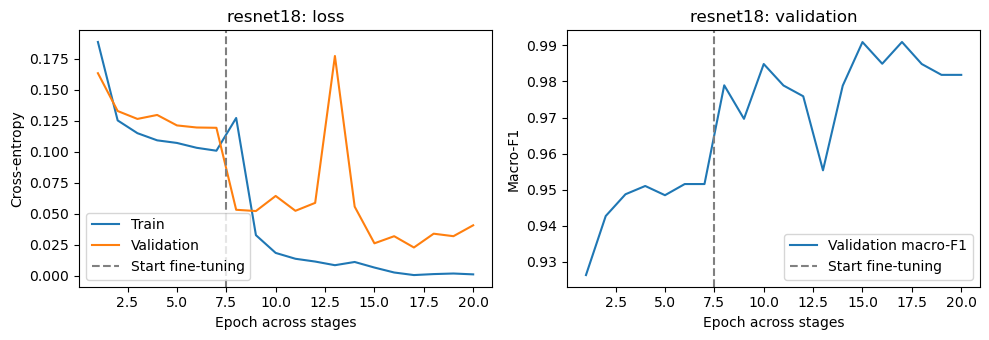

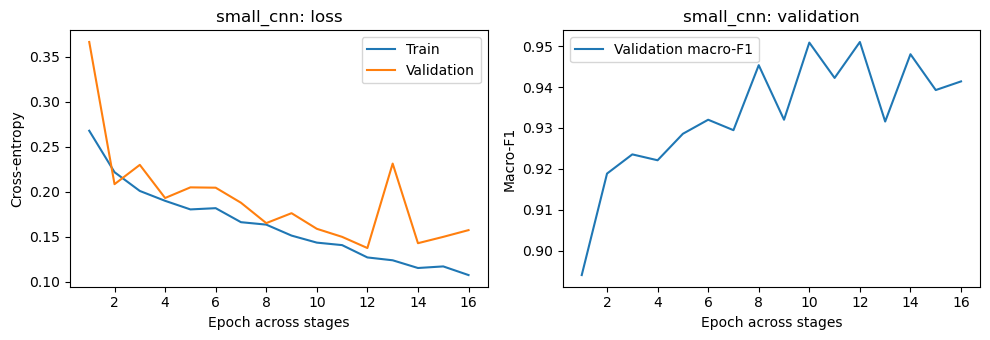

In [18]:
for key, history in histories.items():
    steps = np.arange(1, len(history) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(steps, history['train_loss'], label='Train')
    axes[0].plot(steps, history['val_loss'], label='Validation')
    axes[1].plot(steps, history['val_macro_f1_at_0.5'], label='Validation macro-F1')
    if 'stage' in history:
        boundary = history['stage'].eq('linear_probe').sum() + 0.5
        for axis in axes:
            axis.axvline(boundary, color='gray', linestyle='--', label='Start fine-tuning')
    axes[0].set(title=f'{key}: loss', xlabel='Epoch across stages', ylabel='Cross-entropy')
    axes[1].set(title=f'{key}: validation', xlabel='Epoch across stages', ylabel='Macro-F1')
    for axis in axes:
        axis.legend()
    plt.tight_layout()
    fig.savefig(WORK_DIR / f'{key}_learning_curve.png', dpi=140, bbox_inches='tight')
    plt.show()


### 4.6 Validate the checkpoints

Compute validation metrics for each model.


In [19]:
validation_rows = []
for key, model in models.items():
    val_loss, labels, probabilities, names = predict_dataset(model, val_loader, device)
    assert names == val_df['name'].tolist()
    summary, _, _ = metric_summary(labels, probabilities, thresholds[key])
    validation_rows.append({'model': key, 'loss': val_loss, **summary})
validation_metrics = pd.DataFrame(validation_rows).set_index('model')
display(validation_metrics[['threshold', 'accuracy', 'macro_f1', 'roc_auc', 'pr_auc_crack']].round(4))

,threshold,accuracy,macro_f1,roc_auc,pr_auc_crack
model,,,,,
resnet18,0.5,0.9913,0.9909,0.9996,0.9997
small_cnn,0.5,0.9538,0.9509,0.9808,0.9849


### 4.7 Test results

Predict all 732 test images and report overall and per-class metrics. Keep filenames with predictions for case analysis.


In [20]:
test_loader = DataLoader(
    DamageDataset(test_df, evaluation_transform()),
    batch_size=config['batch_size'], shuffle=False, num_workers=0,
)
results = test_df[['name', 'source_id', 'label', 'path']].copy()
metric_rows, matrices = [], {}
for key, model in models.items():
    loss, labels, probabilities, names = predict_dataset(model, test_loader, device)
    assert names == results['name'].tolist()
    assert np.array_equal(labels, results['label'])
    metrics, matrix, predictions = metric_summary(labels, probabilities, thresholds[key])
    metric_rows.append({'model': key, 'loss': loss, **metrics})
    matrices[key] = matrix
    results[f'{key}_p_crack'] = probabilities
    results[f'{key}_prediction'] = predictions

metrics_df = pd.DataFrame(metric_rows).set_index('model')
# Show every evaluation metric without hiding columns in a wide table.
show_metrics(metrics_df, matrices)


,threshold,accuracy,macro_f1,roc_auc,pr_auc_crack
model,,,,,
resnet18,0.5,0.9604,0.9579,0.9873,0.9915
small_cnn,0.5,0.9057,0.8982,0.9562,0.9575


precision  recall      f1  support
model     class                                        
resnet18  corrosion     0.9850  0.9132  0.9477      288
          crack         0.9462  0.9910  0.9681      444
small_cnn corrosion     0.9469  0.8056  0.8705      288
          crack         0.8850  0.9707  0.9259      444

,TN,FP,FN,TP
model,,,,
resnet18,263,25,4,440
small_cnn,232,56,13,431


### 4.8 Confusion matrices

Upper-right: corrosion predicted as crack. Lower-left: crack predicted as corrosion.


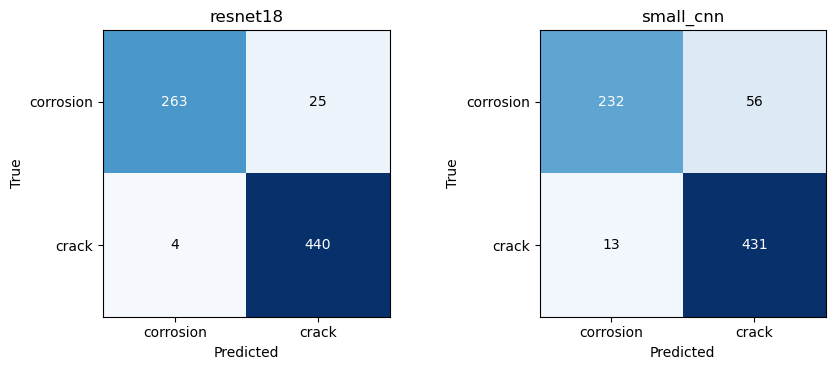

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for axis, (key, matrix) in zip(axes, matrices.items()):
    axis.imshow(matrix, cmap='Blues', vmin=0)
    for i in range(2):
        for j in range(2):
            axis.text(j, i, str(matrix[i, j]), ha='center', va='center',
                      color='white' if matrix[i, j] > matrix.max() / 2 else 'black')
    axis.set(title=key, xlabel='Predicted', ylabel='True', xticks=[0, 1], yticks=[0, 1],
             xticklabels=['corrosion', 'crack'], yticklabels=['corrosion', 'crack'])
plt.tight_layout()
fig.savefig(WORK_DIR / 'confusion_matrices.png', dpi=140, bbox_inches='tight')
plt.show()


### 4.9 ROC, PR and score distributions

Dashed lines show chance ranking. Histograms show the score distributions for each class, with the decision threshold at 0.5.


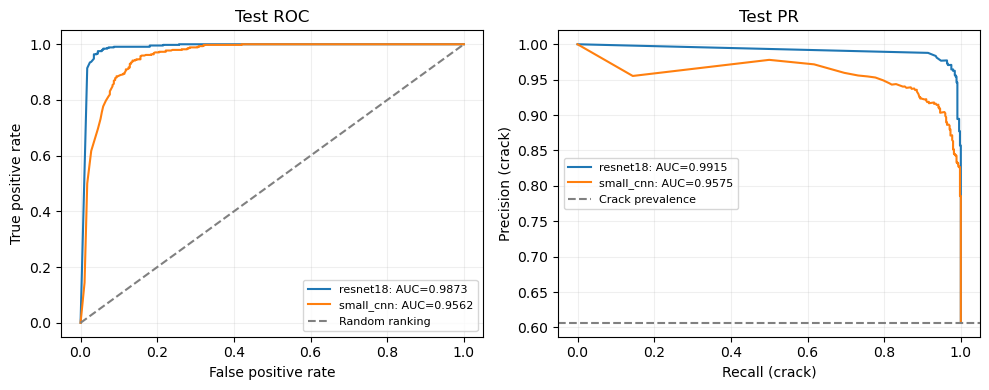

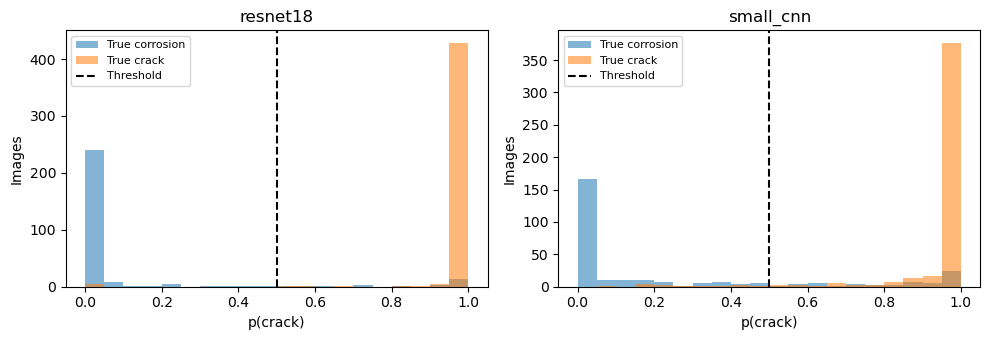

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for key in models:
    probabilities = results[f'{key}_p_crack']
    fpr, tpr, _ = roc_curve(results['label'], probabilities)
    precision, recall, _ = precision_recall_curve(results['label'], probabilities)
    axes[0].plot(fpr, tpr, label=f"{key}: AUC={metrics_df.loc[key, 'roc_auc']:.4f}")
    axes[1].plot(recall, precision, label=f"{key}: AUC={metrics_df.loc[key, 'pr_auc_crack']:.4f}")
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random ranking')
axes[1].axhline(results['label'].mean(), linestyle='--', color='gray', label='Crack prevalence')
axes[0].set(xlabel='False positive rate', ylabel='True positive rate', title='Test ROC')
axes[1].set(xlabel='Recall (crack)', ylabel='Precision (crack)', title='Test PR')
for axis in axes:
    axis.legend(fontsize=8)
    axis.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(WORK_DIR / 'roc_pr.png', dpi=140, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for axis, key in zip(axes, models):
    for label, name in class_names.items():
        axis.hist(results.loc[results['label'].eq(label), f'{key}_p_crack'],
                  bins=np.linspace(0, 1, 21), alpha=0.55, label=f'True {name}')
    axis.axvline(thresholds[key], color='black', linestyle='--', label='Threshold')
    axis.set(title=key, xlabel='p(crack)', ylabel='Images')
    axis.legend(fontsize=8)
plt.tight_layout()
fig.savefig(WORK_DIR / 'probability_distribution.png', dpi=140, bbox_inches='tight')
plt.show()

### 4.10 ResNet-18 predictions and Grad-CAM

Show one seeded example from each group: correct corrosion, correct crack, misclassified corrosion and misclassified crack.

`resnet_errors` holds all mistakes and is saved to `resnet_errors.csv`. Each panel shows the original crop, padded input and predicted-class Grad-CAM.


In [2]:
resnet_results = results.copy()
resnet_results['correct'] = resnet_results['resnet18_prediction'].eq(resnet_results['label'])
resnet_results['predicted_confidence'] = np.where(
    resnet_results['resnet18_prediction'].eq(1),
    resnet_results['resnet18_p_crack'], 1 - resnet_results['resnet18_p_crack'],
)
# Keep the full error table available without displaying it.
resnet_errors = resnet_results.loc[~resnet_results['correct']].copy()

selected_examples = pd.concat([
    group.sample(n=1, random_state=config['seed'])
    for _, group in resnet_results.groupby(['correct', 'label'], sort=True)
]).sort_values(['correct', 'label'], ascending=[False, True])


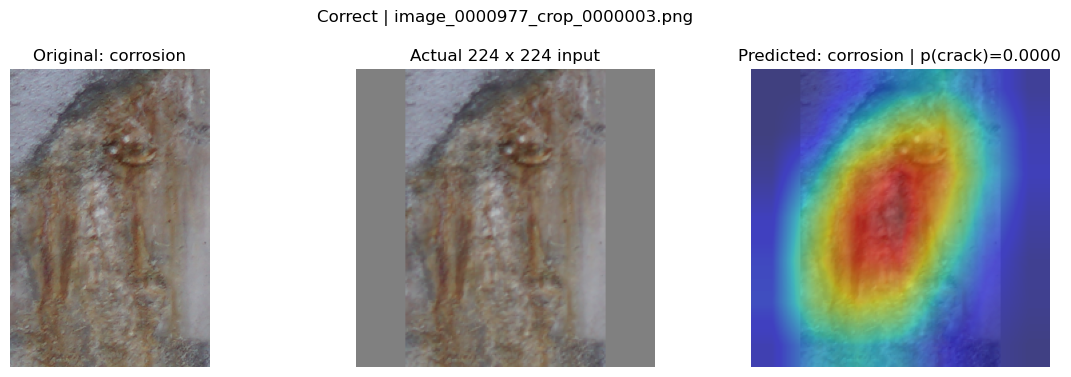

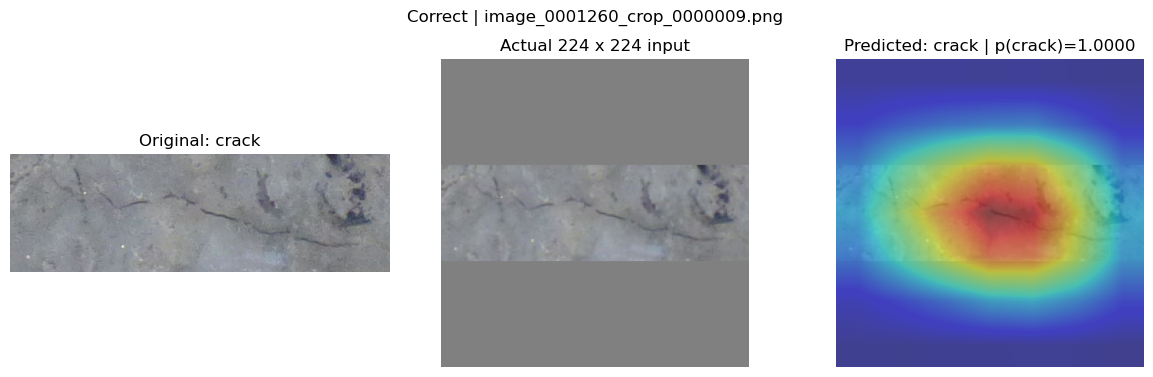

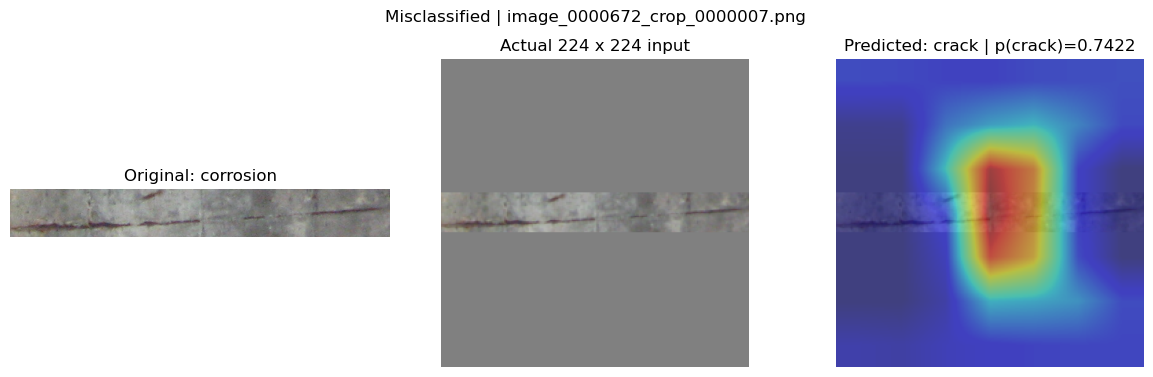

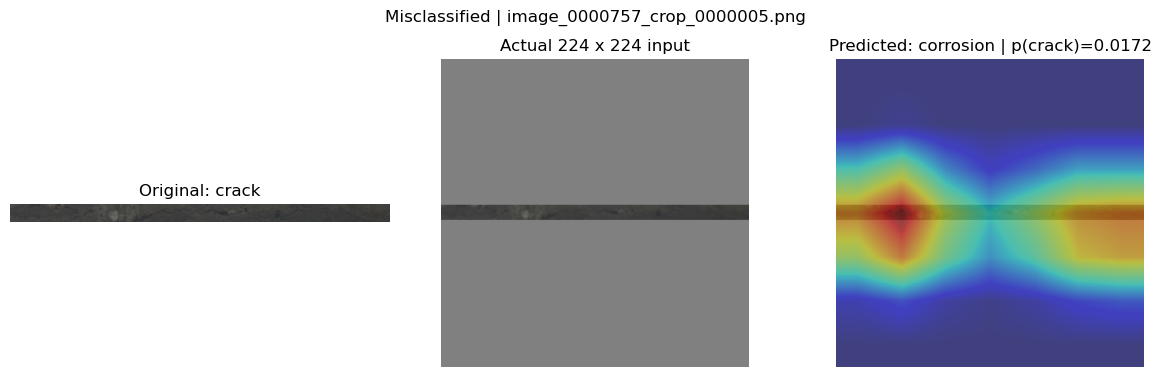

In [3]:
from src.gradcam import grad_cam

for _, row in selected_examples.iterrows():
    with Image.open(row['path']) as image:
        raw = ImageOps.exif_transpose(image).convert('RGB')
    padded = resize_and_pad(raw)
    tensor = evaluation_transform()(raw).unsqueeze(0).to(device)
    target = int(row['resnet18_prediction'])
    # Explain the predicted class at the last residual block.
    heatmap = grad_cam(models['resnet18'], models['resnet18'].layer4[-1], tensor, target)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    axes[0].imshow(raw)
    axes[0].set_title(f"Original: {class_names[int(row['label'])]}")
    axes[1].imshow(padded)
    axes[1].set_title('Actual 224 x 224 input')
    axes[2].imshow(padded)
    axes[2].imshow(heatmap, cmap='jet', alpha=0.5, vmin=0, vmax=1)
    axes[2].set_title(f"Predicted: {class_names[target]} | p(crack)={row['resnet18_p_crack']:.4f}")
    for axis in axes:
        axis.axis('off')
    status = 'Correct' if row['correct'] else 'Misclassified'
    fig.suptitle(f"{status} | {row['name']}")
    plt.tight_layout()
    fig.savefig(WORK_DIR / f"resnet_gradcam_{Path(row['name']).stem}.png", dpi=140)
    plt.show()
resnet_errors.drop(columns='path').to_csv(WORK_DIR / 'resnet_errors.csv', index=False)

## 5. Feature analysis

Calculate 49 features from original crops resized within 192 x 192, without padding.

| Group | Count |
|---|---:|
| RGB statistics | 12 |
| Brightness and saturation | 9 |
| Red excess and rust colour | 4 |
| Edges and local texture | 12 |
| Colour and edges in four regions | 12 |


In [25]:
import lightgbm as lgb
from joblib import Parallel, delayed
from src.features import extract_simple_features, source_class_weights

feature_tables = {}
for split, table in [('train', train_df), ('val', val_df), ('test', test_df)]:
    values = Parallel(n_jobs=4, batch_size=16, prefer='threads')(
        delayed(extract_simple_features)(path) for path in table['path']
    )
    feature_tables[split] = pd.DataFrame(values, index=table['name'])
    assert feature_tables[split].shape == (len(table), 49)
    assert np.isfinite(feature_tables[split].to_numpy()).all()
    print(split, feature_tables[split].shape)

train_features = feature_tables['train']
val_features = feature_tables['val']
test_features = feature_tables['test']
display(train_features.head())

train (2512, 49)
val (346, 49)
test (732, 49)


,red_mean,red_std,red_q10,red_q90,green_mean,green_std,green_q10,green_q90,blue_mean,blue_std,...,edge_r1c1,red_excess_r1c2,saturation_r1c2,edge_r1c2,red_excess_r2c1,saturation_r2c1,edge_r2c1,red_excess_r2c2,saturation_r2c2,edge_r2c2
name,,,,,,,,,,,,,,,,,,,,,
image_0000005_crop_0000001.png,0.503050,0.095700,0.411765,0.600000,0.460491,0.095580,0.368627,0.564706,0.372905,0.100855,...,0.012080,0.084815,0.293584,0.020476,0.081444,0.226457,0.010033,0.075220,0.202927,0.015803
image_0000005_crop_0000002.png,0.607193,0.149202,0.381569,0.776471,0.562266,0.152658,0.341176,0.756863,0.491106,0.172556,...,0.013439,0.109358,0.347630,0.034477,0.043875,0.086524,0.019901,0.084836,0.178808,0.042041
image_0000034_crop_0000001.png,0.472216,0.071371,0.380392,0.560784,0.459847,0.083226,0.349020,0.560784,0.440814,0.096903,...,0.031093,0.026092,0.087486,0.027791,0.022256,0.093802,0.031219,-0.009350,0.043622,0.019919
image_0000034_crop_0000002.png,0.304220,0.067345,0.227451,0.372549,0.294611,0.070295,0.211765,0.364706,0.270574,0.073605,...,0.013147,0.026528,0.169290,0.014123,0.018035,0.089094,0.013350,0.024070,0.141825,0.010479
image_0000046_crop_0000001.png,0.640195,0.064453,0.596078,0.705882,0.642443,0.068148,0.596078,0.709804,0.644642,0.079630,...,0.011851,0.002664,0.025304,0.017233,-0.010178,0.030417,0.009372,0.003097,0.024833,0.015947


### 5.1 How the main factors are calculated

For RGB values in [0, 1]:

| Factor | Calculation |
|---|---|
| saturation_std | std((max(R,G,B) - min(R,G,B)) / max(max(R,G,B), 1e-6)) |
| green_std | std(G) |
| gray_std | std(0.299R + 0.587G + 0.114B) |
| red_excess_std | std(R - (G+B)/2) |
| blue_q10 | 10th percentile of B |
| dark_pixel_fraction | Fraction of grey values below 0.25 |


### 5.2 Factor distributions

Compare training class means and distributions for colour and brightness features.


,corrosion_mean,crack_mean
red_mean,0.5173,0.6070
red_std,0.1185,0.0497
red_q10,0.3525,0.5454
red_q90,0.6561,0.6601
green_mean,0.4756,0.5859
green_std,0.1317,0.0526
green_q10,0.2920,0.5204
green_q90,0.6313,0.6422
blue_mean,0.4299,0.5485
blue_std,0.1319,0.0548


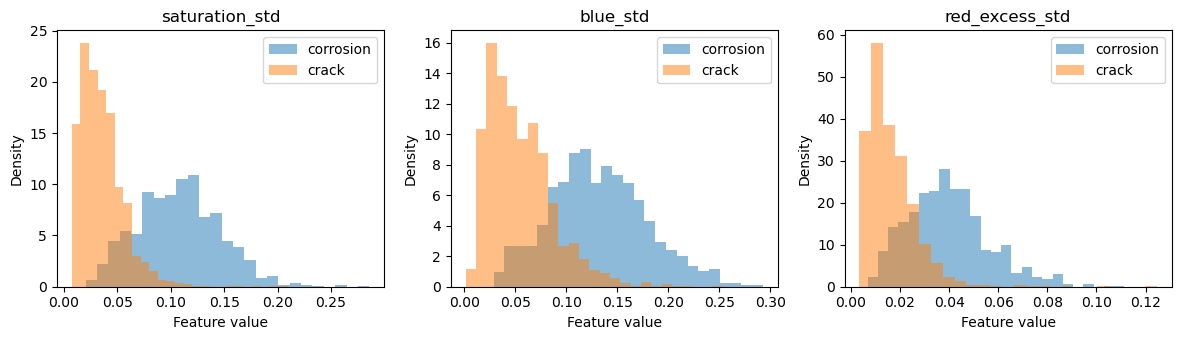

In [26]:
factor_summary = pd.DataFrame({
    'corrosion_mean': train_features.iloc[np.flatnonzero(train_df['label'].to_numpy() == 0)].mean(),
    'crack_mean': train_features.iloc[np.flatnonzero(train_df['label'].to_numpy() == 1)].mean(),
})
display(factor_summary.round(4))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for axis, column in zip(axes, ['saturation_std', 'blue_std', 'red_excess_std']):
    for label in (0, 1):
        axis.hist(train_features.loc[train_df.loc[train_df.label.eq(label), 'name'], column],
                  bins=25, alpha=0.5, density=True, label=class_names[label])
    axis.set(title=column, xlabel='Feature value', ylabel='Density')
    axis.legend()
plt.tight_layout()
fig.savefig(WORK_DIR / 'training_factors.png', dpi=140)
plt.show()

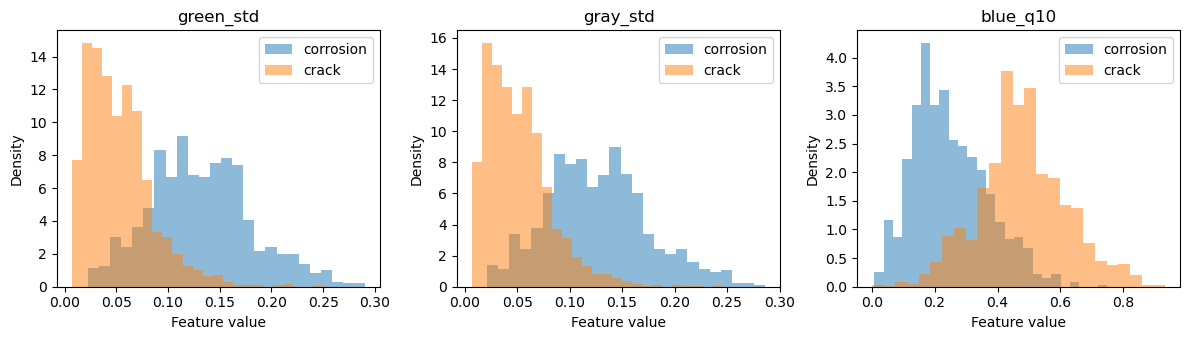

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for axis, column in zip(axes, ['green_std', 'gray_std', 'blue_q10']):
    for label in (0, 1):
        axis.hist(train_features.loc[train_df.loc[train_df.label.eq(label), 'name'], column],
                  bins=25, density=True, alpha=0.5, label=class_names[label])
    axis.set(title=column, xlabel='Feature value', ylabel='Density')
    axis.legend()
plt.tight_layout()
fig.savefig(WORK_DIR / 'brightness_factors.png', dpi=140)
plt.show()

## 6. ML Model for the prediction

Combine the 49 features using 400 trees, learning rate 0.03 and 15 leaves. Train on the 2,512 original crops, weighting sources equally before balancing class weights.

Load `MODEL_DIR/lightgbm.txt` when available; otherwise fit and save it. Training mode always refits LightGBM.


In [28]:
lgbm_path = MODEL_DIR / 'lightgbm.txt'
if RUN_TRAINING or not lgbm_path.is_file():
    lgbm_classifier = lgb.LGBMClassifier(
        objective='binary', n_estimators=400, learning_rate=0.03,
        num_leaves=15, min_child_samples=30, colsample_bytree=0.85,
        reg_alpha=0.10, reg_lambda=2.0, n_jobs=4,
        deterministic=True, force_col_wise=True, verbosity=-1,
        random_state=config['seed'],
    )
    # Balance source contributions and class weights.
    lgbm_classifier.fit(train_features, train_df['label'].to_numpy(),
                        sample_weight=source_class_weights(train_df))
    lgbm_model = lgbm_classifier.booster_
    lgbm_path = WORK_DIR / 'models' / 'lightgbm.txt'
    lgbm_path.parent.mkdir(parents=True, exist_ok=True)
    lgbm_path.write_text(lgbm_model.model_to_string(), encoding='utf-8')
else:
    lgbm_model = lgb.Booster(model_str=lgbm_path.read_text(encoding='utf-8'))
assert lgbm_model.feature_name() == train_features.columns.tolist()
print('LightGBM model:', lgbm_path)

LightGBM model: d:\MYL_个人\个人\EDF\Coding_Test\deliverables\EDF_code_project\models\lightgbm.txt


### 6.1 Validation and test results

Use the same evaluation images and threshold 0.5 as the neural networks.


In [29]:
for split, table, features in [('val', val_df, val_features), ('test', test_df, test_features)]:
    probabilities = lgbm_model.predict(features)
    summary, matrix, predictions = metric_summary(table['label'].to_numpy(), probabilities, 0.5)
    if split == 'val':
        validation_metrics.loc['lightgbm', list(summary)] = list(summary.values())
    else:
        metrics_df.loc['lightgbm', list(summary)] = list(summary.values())
        matrices['lightgbm'] = matrix
        results['lightgbm_p_crack'] = probabilities
        results['lightgbm_prediction'] = predictions
display(validation_metrics.loc[['lightgbm']].drop(columns='loss').round(4))
# Use the same test report as the neural networks.
show_metrics(metrics_df.loc[['lightgbm']], {'lightgbm': matrices['lightgbm']})

,threshold,accuracy,macro_f1,roc_auc,pr_auc_crack,corrosion_precision,corrosion_recall,corrosion_f1,corrosion_support,crack_precision,crack_recall,crack_f1,crack_support
model,,,,,,,,,,,,,
lightgbm,0.5,0.9393,0.9368,0.9807,0.9848,0.9143,0.9343,0.9242,137.0,0.9563,0.9426,0.9494,209.0


,threshold,accuracy,macro_f1,roc_auc,pr_auc_crack
model,,,,,
lightgbm,0.5,0.9098,0.9048,0.9737,0.9833


precision  recall      f1  support
model    class                                        
lightgbm corrosion     0.9022  0.8646  0.8830      288
         crack         0.9145  0.9392  0.9267      444

,TN,FP,FN,TP
model,,,,
lightgbm,249,39,27,417


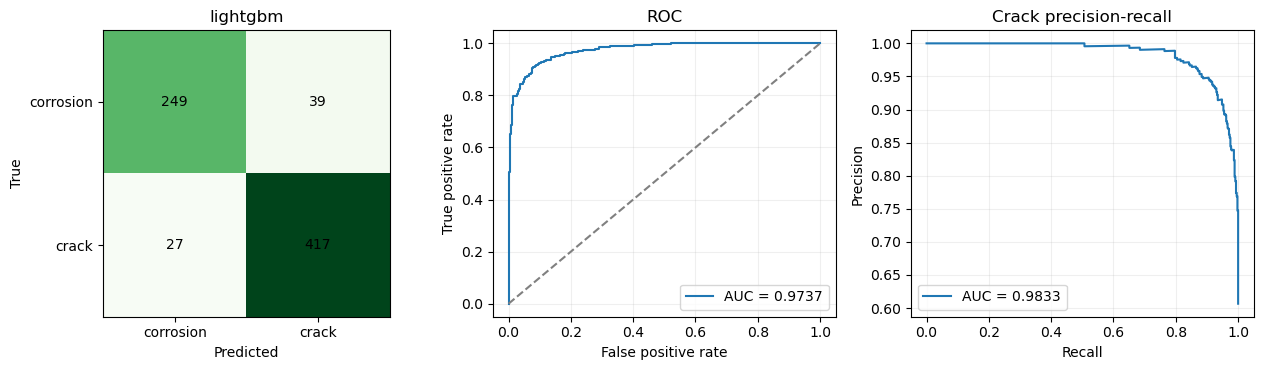

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), squeeze=False)
for row, key in enumerate(['lightgbm']):
    matrix = matrices[key]
    axes[row, 0].imshow(matrix, cmap='Greens')
    for i in range(2):
        for j in range(2):
            axes[row, 0].text(j, i, str(matrix[i, j]), ha='center', va='center')
    axes[row, 0].set(title=key, xlabel='Predicted', ylabel='True',
                     xticks=[0, 1], yticks=[0, 1],
                     xticklabels=['corrosion', 'crack'], yticklabels=['corrosion', 'crack'])
    probs = results[f'{key}_p_crack'].to_numpy()
    fpr, tpr, _ = roc_curve(results['label'], probs)
    precision, recall, _ = precision_recall_curve(results['label'], probs)
    axes[row, 1].plot(fpr, tpr, label=f"AUC = {metrics_df.loc[key, 'roc_auc']:.4f}")
    axes[row, 1].plot([0, 1], [0, 1], '--', color='grey')
    axes[row, 1].set(title='ROC', xlabel='False positive rate', ylabel='True positive rate')
    axes[row, 2].plot(recall, precision, label=f"AUC = {metrics_df.loc[key, 'pr_auc_crack']:.4f}")
    axes[row, 2].set(title='Crack precision-recall', xlabel='Recall', ylabel='Precision')
    for axis in axes[row, 1:]:
        axis.legend()
        axis.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(WORK_DIR / 'lightgbm_metrics.png', dpi=140)
plt.show()

### 6.2 Feature importance

Rank features by their total split gain. Correlated features can share importance.


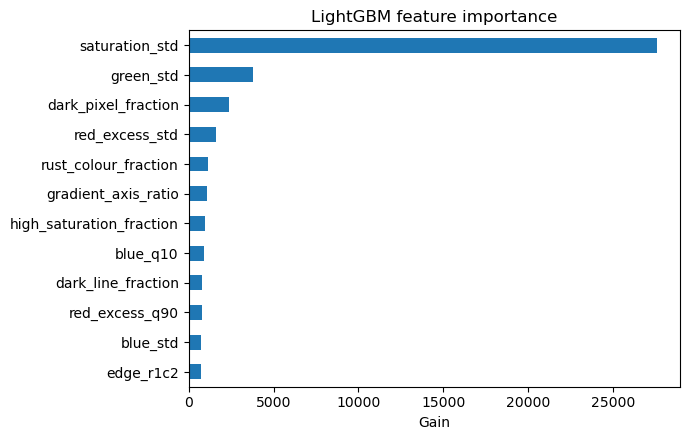

In [31]:
importance = pd.Series(lgbm_model.feature_importance(importance_type='gain'),
                       index=lgbm_model.feature_name(), name='gain').sort_values()
importance.tail(12).plot.barh(figsize=(7, 4.5), title='LightGBM feature importance')
plt.xlabel('Gain')
plt.tight_layout()
plt.savefig(WORK_DIR / 'feature_importance.png', dpi=140, bbox_inches='tight')
plt.show()